### **1. Install tacoreader**

## **2. Load a TACO compliant dataset**

In [1]:
import autoroot
import tacoreader
from shapely import wkb
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch import LightningDataModule
from loguru import logger

from src.finetuning.dataloader import Cloud3DDataModule
from src.finetuning.transforms import GeoSatTransform
from src.finetuning.model import UNetAutoencoder


/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [ ]:
tacoreader.use("pandas")
                       
goes = tacoreader.load("/data/databases/CLOUD_3D/pretraining/tacos/finetune/goes/")
himawari = tacoreader.load("/data/databases/CLOUD_3D/pretraining/tacos/finetune/himawari/")
msg = tacoreader.load("/data/databases/CLOUD_3D/pretraining/tacos/finetune/msi/")

# Concat
full_dataset = tacoreader.concat([goes, himawari, msg])
dataset = full_dataset.data#.to_pandas()



In [3]:
SPLITS_DICT = {
    "train": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(2, 23).tolist(),
    },
    "val": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(24, 27).tolist(),
    },
    "test": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(28, 32).tolist(),
    },
}

def add_split_column(df: pd.DataFrame, date_col: str = "date", split_col: str = "split") -> pd.DataFrame:
    #df = df.copy()

    # ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])

    y = df[date_col].dt.year
    m = df[date_col].dt.month
    d = df[date_col].dt.day

    # start with NaN / unknown
    split = np.full((len(df),), np.nan, dtype=object)
    #split = pd.Series(pd.NA, index=df.index, dtype="string")

    for name, spec in SPLITS_DICT.items():
        mask = (
            y.isin(spec["years"]) &
            m.isin(spec["months"]) &
            d.isin(spec["days"])
        )
        #split.loc[mask] = name
        split[mask] = name

    df[split_col] = split
    return df


In [4]:
dataset = add_split_column(dataset, date_col="stac:time_start", split_col="split")
dataset

                       cloud3d:cloudsat_id  cloud3d:cyclone  \
0   2018283153908_66322_CS_merged_no_flxhr            False   
1   2018283153908_66322_CS_merged_no_flxhr            False   
2   2018285151645_66351_CS_merged_no_flxhr            False   
3   2018293152524_66468_CS_merged_no_flxhr            False   
4   2018293152524_66468_CS_merged_no_flxhr            False   
..                                     ...              ...   
95  2019081152809_68704_CS_merged_no_flxhr            False   
96  2019081152809_68704_CS_merged_no_flxhr            False   
97  2019084154336_68748_CS_merged_no_flxhr            False   
98  2019084154336_68748_CS_merged_no_flxhr            False   
99  2019086152104_68777_CS_merged_no_flxhr            False   

                             cloud3d:geostationary_id  cloud3d:has_flxhr  \
0   OR_ABI-L2-MCMIPF-M3_G16_s20182831615382_e20182...              False   
1   OR_ABI-L2-MCMIPF-M3_G16_s20182831615382_e20182...              False   
2   OR_ABI-L2-M

In [5]:
transform = GeoSatTransform(patch_size=[256, 256])
dm = Cloud3DDataModule(dataset, transform)

2026-02-20 19:46:41.863 | INFO     | src.finetuning.dataloader:__init__:28 - There are 270072 files in taco dataset
2026-02-20 19:46:43.179 | INFO     | src.finetuning.dataloader:__init__:57 - MSG DataModule initialized ...
2026-02-20 19:46:43.180 | INFO     | src.finetuning.dataloader:__init__:58 - Length of train dataset: 185629
2026-02-20 19:46:43.181 | INFO     | src.finetuning.dataloader:__init__:59 - Length of test dataset: 31166
2026-02-20 19:46:43.182 | INFO     | src.finetuning.dataloader:__init__:60 - Length of val dataset: 26462


In [6]:
model = UNetAutoencoder(lr=1e-3,)

In [7]:
dir_save = "/data/users/emiliano/3DcloudsData/output/notebooks/"
file_nm = "ae-{epoch:03d}-{val_loss:.4f}"
dir_save+file_nm

'/data/users/emiliano/3DcloudsData/output/notebooks/ae-{epoch:03d}-{val_loss:.4f}'

In [8]:
checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",      # or "train/loss"
    mode="min",
    save_top_k=3,
    save_last=True,         # saves last.ckpt
    filename=file_nm,
)

logger = CSVLogger(save_dir=dir_save, name="cloud_ae")

trainer = pl.Trainer(accelerator="gpu", devices=1, max_epochs=3, 
                     limit_train_batches=0.01,
                     limit_val_batches=0.01,
                    limit_test_batches=0.01,
                        callbacks=[checkpoint_cb],
                        logger=logger)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [9]:
trainer.fit(model, datamodule=dm)

You are using a CUDA device ('NVIDIA RTX A5500') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ MSELoss          │      0 │ train │     0 │
│ 1 │ net       │ UNet2Dto3D_Mixed │ 24.5 M │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 24.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.5 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 193                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/utilities/
data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 4. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve 
performance.

`Trainer.fit` stopped: `max_epochs=3` reached.


In [10]:
version = "9"
df = pd.read_csv(dir_save+"cloud_ae/version_"+version+"/metrics.csv")
print(df.head())

   epoch  step  train_loss_epoch  train_loss_step  train_mse  train_psnr  \
0      0    49               NaN         0.035555        NaN         NaN   
1      0    99               NaN         0.007781        NaN         NaN   
2      0   149               NaN         0.046281        NaN         NaN   
3      0   199               NaN         0.110662        NaN         NaN   
4      0   249               NaN         0.042121        NaN         NaN   

   train_rmse  val_loss  val_mse  val_psnr  val_rmse  
0         NaN       NaN      NaN       NaN       NaN  
1         NaN       NaN      NaN       NaN       NaN  
2         NaN       NaN      NaN       NaN       NaN  
3         NaN       NaN      NaN       NaN       NaN  
4         NaN       NaN      NaN       NaN       NaN  


In [11]:
# remove rows with NaN val/loss
df.dropna(subset=['val_loss'])

,epoch,step,train_loss_epoch,train_loss_step,train_mse,train_psnr,train_rmse,val_loss,val_mse,val_psnr,val_rmse
9,0,463,NaN,NaN,NaN,NaN,NaN,0.036338,0.036338,24.630795,0.179572
20,1,927,NaN,NaN,NaN,NaN,NaN,0.026898,0.026898,26.933868,0.148459
31,2,1391,NaN,NaN,NaN,NaN,NaN,0.027348,0.027348,27.142937,0.151542


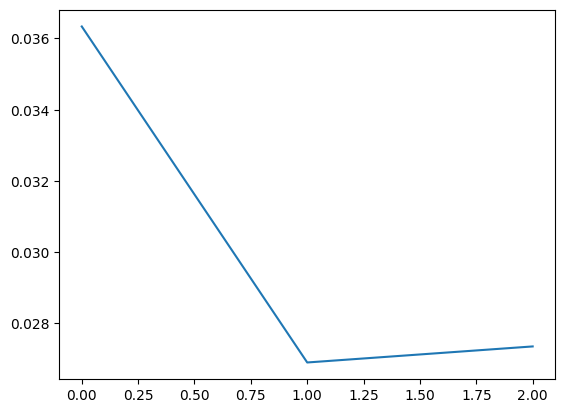

In [12]:
# get validation curves from csv
import matplotlib.pyplot as plt
plt.plot(df.dropna(subset=['val_loss'])["epoch"], df.dropna(subset=['val_loss'])["val_loss"], label="val_loss")


In [13]:
# train model for another 3 epochs
trainer = pl.Trainer(accelerator="gpu", devices=1, max_epochs=3+3, 
                     limit_train_batches=0.01,
                     limit_val_batches=0.01,
                    limit_test_batches=0.01,
                        callbacks=[checkpoint_cb],
                        logger=logger)
trainer.fit(model, datamodule=dm, ckpt_path=checkpoint_cb.best_model_path)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /data/users/emiliano/3DcloudsData/output/notebooks/cloud_ae/version_9/checkpoints exists and is not empty.
Restoring states from the checkpoint path at /data/users/emiliano/3DcloudsData/output/notebooks/cloud_ae/version_9/checkpoints/ae-epoch=001-val_loss=0.0269.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion │ MSELoss          │      0 │ train │     0 │
│ 1 │ net       │ UNet2Dto3D_Mixed │ 24.5 M │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 24.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.5 M                                                                                               
Total estimated model params size (MB): 98                                                                         
Modules in train mode: 193                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Restored all states from the checkpoint at /data/users/emiliano/3DcloudsData/output/notebooks/cloud_ae/version_9/checkpoints/ae-epoch=001-val_loss=0.0269.ckpt


Output()

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.

/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/co
nnectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve 
performance.

`Trainer.fit` stopped: `max_epochs=6` reached.


In [14]:
df = pd.read_csv(dir_save+"cloud_ae/version_"+version+"/metrics.csv")
df.dropna(subset=['val_loss'])

,epoch,step,train_loss_epoch,train_loss_step,train_mse,train_psnr,train_rmse,val_loss,val_mse,val_psnr,val_rmse
9,0,463,NaN,NaN,NaN,NaN,NaN,0.036338,0.036338,24.630795,0.179572
20,1,927,NaN,NaN,NaN,NaN,NaN,0.026898,0.026898,26.933868,0.148459
31,2,1391,NaN,NaN,NaN,NaN,NaN,0.027348,0.027348,27.142937,0.151542
42,2,1391,NaN,NaN,NaN,NaN,NaN,0.025876,0.025876,27.166716,0.146827
54,3,1855,NaN,NaN,NaN,NaN,NaN,0.029237,0.029237,26.053061,0.158665
65,4,2319,NaN,NaN,NaN,NaN,NaN,0.029483,0.029483,26.385038,0.158667
76,5,2783,NaN,NaN,NaN,NaN,NaN,0.023093,0.023093,27.202379,0.139163


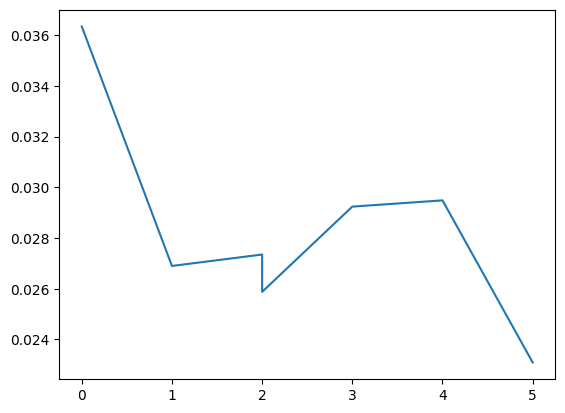

In [15]:
plt.plot(df.dropna(subset=['val_loss'])["epoch"], df.dropna(subset=['val_loss'])["val_loss"], label="val_loss")


In [16]:
df

,epoch,step,train_loss_epoch,train_loss_step,train_mse,train_psnr,train_rmse,val_loss,val_mse,val_psnr,val_rmse
0,0,49,NaN,0.035555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,99,NaN,0.007781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,149,NaN,0.046281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,199,NaN,0.110662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,249,NaN,0.042121,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
73,5,2649,NaN,0.024686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,5,2699,NaN,0.046208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75,5,2749,NaN,0.032814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,5,2783,NaN,NaN,NaN,NaN,NaN,0.023093,0.023093,27.202379,0.139163


In [17]:
#look at metrics
trainer.test(model, datamodule=dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/users/emiliano/pixi_env2/extreme/.pixi/envs/default/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.031075000762939453    │
│         test_mse          │   0.031075000762939453    │
│         test_psnr         │    26.070016860961914     │
│         test_rmse         │    0.16185416281223297    │
└───────────────────────────┴───────────────────────────┘

[{'test_mse': 0.031075000762939453,
  'test_rmse': 0.16185416281223297,
  'test_psnr': 26.070016860961914,
  'test_loss': 0.031075000762939453}]